<a href="https://colab.research.google.com/github/dishanayak144/Housing-Prices-Project/blob/main/RES_RENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
bbsr= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL RENT DATA.xlsx', sheet_name='BBSR')
kk= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL RENT DATA.xlsx', sheet_name='KOLKATA')
patna= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL RENT DATA.xlsx', sheet_name='PATNA')
ranchi= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL RENT DATA.xlsx', sheet_name='RANCHI')
jam= pd.read_excel('/content/drive/MyDrive/EAST INDIA DATA/RESIDENTIAL RENT DATA.xlsx', sheet_name='JAMSHEDPUR')

In [ ]:
bbsr.columns

Index(['tupleNew__locationName', 'tupleNew__propType', 'tupleNew__bOld',
       'PRICE', 'ADVANCE', 'ADV', 'AREA', 'BHK', 'descPtag_undefined',
       'tupleNew__pbL2'],
      dtype='object')

In [ ]:
kk.columns

Index(['tupleNew__locationName', 'PRICE', 'AREA', 'BHK', 'HIGHLIGHT 1',
       'HIGHLIGHT 2', 'descPtag_undefined', 'OWNER TYPE', 'ADVANCE', 'ADV',
       'C1', 'AMENITIES'],
      dtype='object')

In [ ]:
patna.columns

Index(['tupleNew__locationName', 'priceee', 'PRICE', 'ADVaa', 'ADV', 'AREA',
       'BHK', 'HIGHLIGHT 1', 'tupleNew__pbL2', 'Text After Delimiter'],
      dtype='object')

In [ ]:
ranchi.columns

Index(['Column3', 'PRICE', 'Column6', 'ADVa', 'ADV', 'AREA', 'BHK', 'Column13',
       'HIGHLIGHT 1', 'HIGHLIGHT 2', 'AMENITIES', 'OWNER TYPE'],
      dtype='object')

In [ ]:
jam.columns

Index(['tupleNew__locationName', 'tupleNew__bOld', 'PRICE', 'ADVANCE', 'ADV',
       'AREA', 'BHK', 'HIGHLIGHT 1', 'OWNER TYPE'],
      dtype='object')

## ***BBSR ***

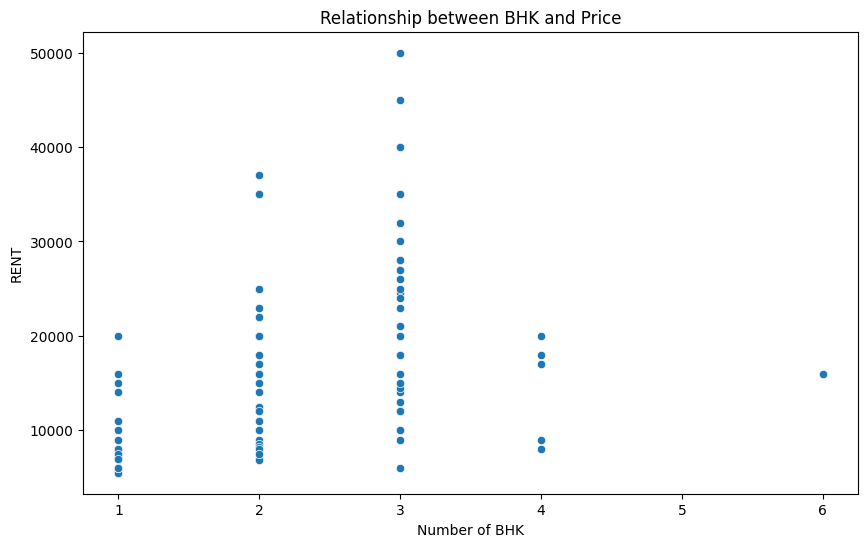

          PRICE       ADV      AREA       BHK
PRICE  1.000000  0.089365 -0.086463  0.431216
ADV    0.089365  1.000000  0.064899  0.023626
AREA  -0.086463  0.064899  1.000000 -0.021193
BHK    0.431216  0.023626 -0.021193  1.000000


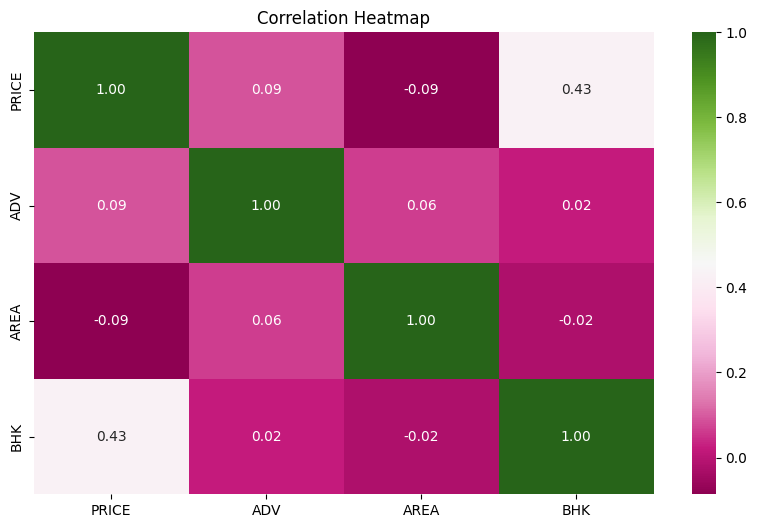

In [ ]:
##########################################################
#######################BBSR#############################


# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='PRICE', data=bbsr)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('RENT')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = bbsr[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = bbsr[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#######################   BBSR#############################

In [ ]:
!pip install tensorflow

In [ ]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# Assuming 'bbsr' is your DataFrame
# Select features and target variable
X = bbsr[['BHK', 'AREA']]
y = bbsr['PRICE']

# Remove rows with NaN values in the target variable 'PRICE'
bbsr = bbsr.dropna(subset=['PRICE'])  # Drop rows with NaN in 'PRICE'

# Update X and y after removing NaN values
X = bbsr[['BHK', 'AREA']]
y = bbsr['PRICE']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a simple neural network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(1) # Output layer for regression
])

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100, # Adjust as needed
    batch_size=32, # Adjust as needed
    validation_split=0.2 # Use a portion of training data for validation
)

# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Mean Squared Error on Test Data: {loss}")

# Make predictions
y_pred = model.predict(X_test)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - loss: 334049280.0000 - val_loss: 369550720.0000
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 324977536.0000 - val_loss: 369549856.0000
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 328051968.0000 - val_loss: 369548960.0000
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 345677760.0000 - val_loss: 369548128.0000
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 319501760.0000 - val_loss: 369547264.0000
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 316143616.0000 - val_loss: 369546400.0000
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 310006976.0000 - val_loss: 369545568.0000
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 363222496.0000 - val_loss: 369544704.0000
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 351912000.0000 - val_loss: 369543840.0000
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 351934400.0000 - val_loss: 369542944.0000
Epoch 11/1

# **KOLKATA**

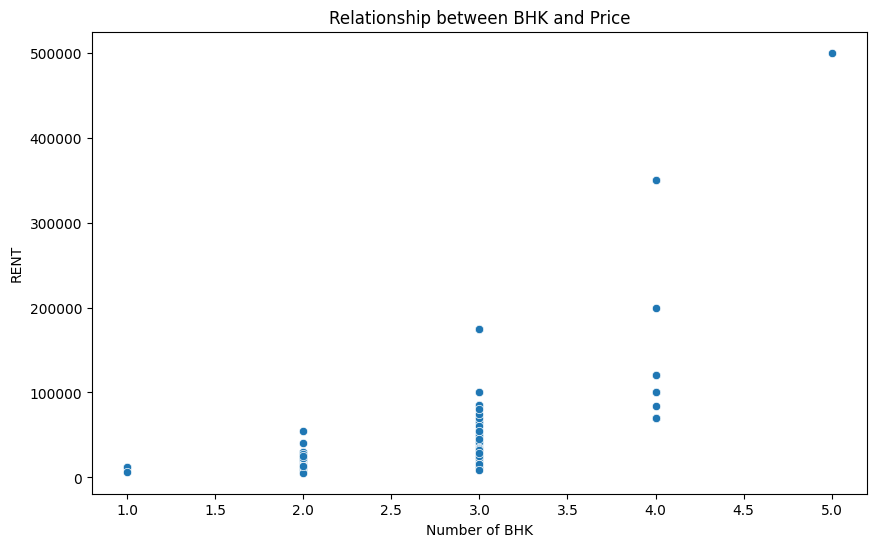

              PRICE       ADV      AREA       BHK  AMENITIES
PRICE      1.000000  0.018561  0.785278  0.588124   0.179604
ADV        0.018561  1.000000 -0.026850 -0.040544   0.104090
AREA       0.785278 -0.026850  1.000000  0.706950   0.132538
BHK        0.588124 -0.040544  0.706950  1.000000   0.182525
AMENITIES  0.179604  0.104090  0.132538  0.182525   1.000000


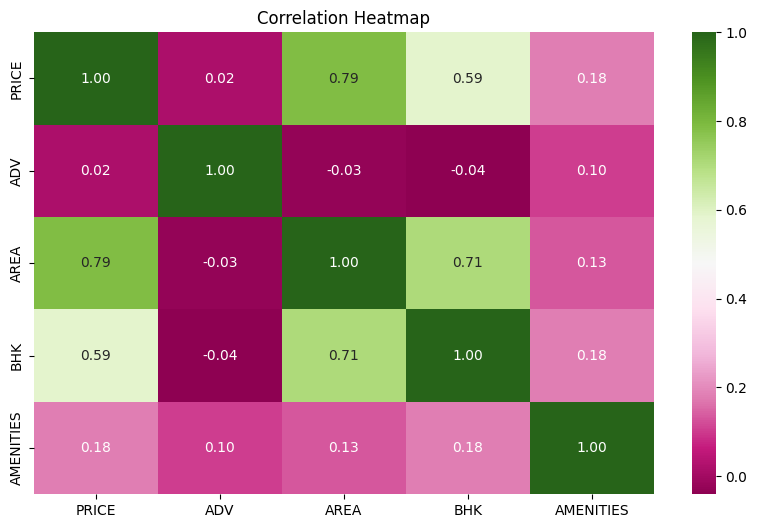

In [ ]:
##########################################################
####################### KOLKATA  #############################


# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='PRICE', data=kk)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('RENT')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK', 'AMENITIES']
subset_df = kk[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK', 'AMENITIES']
subset_df = kk[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#######################  KOLKATA   #############################

# **PATNA**

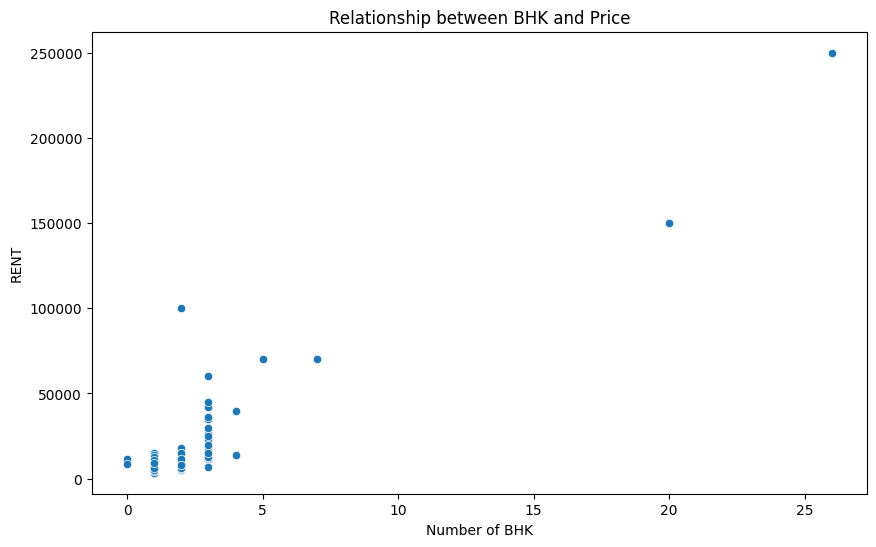

          PRICE       ADV      AREA       BHK
PRICE  1.000000  0.147363  0.429982  0.908390
ADV    0.147363  1.000000  0.026281  0.088685
AREA   0.429982  0.026281  1.000000  0.456613
BHK    0.908390  0.088685  0.456613  1.000000


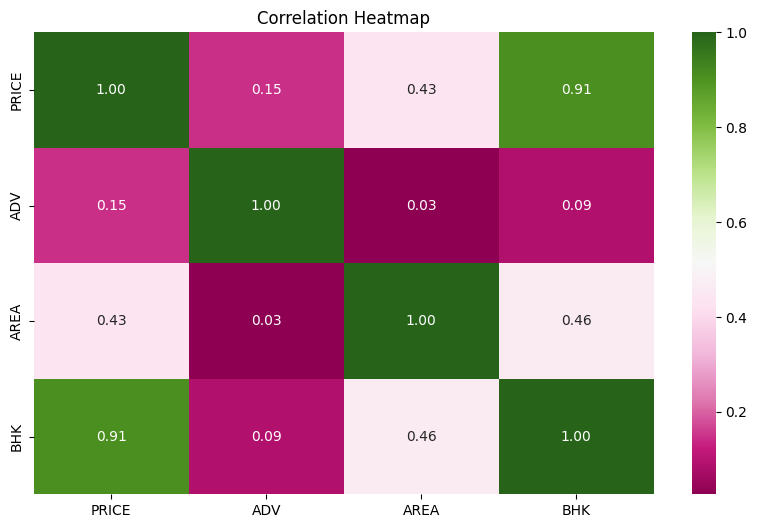

In [ ]:
##########################################################
####################### PATNA  #############################


# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='PRICE', data=patna)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('RENT')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = patna[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = patna[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#######################  PATNA   #############################

# **RANCHI**

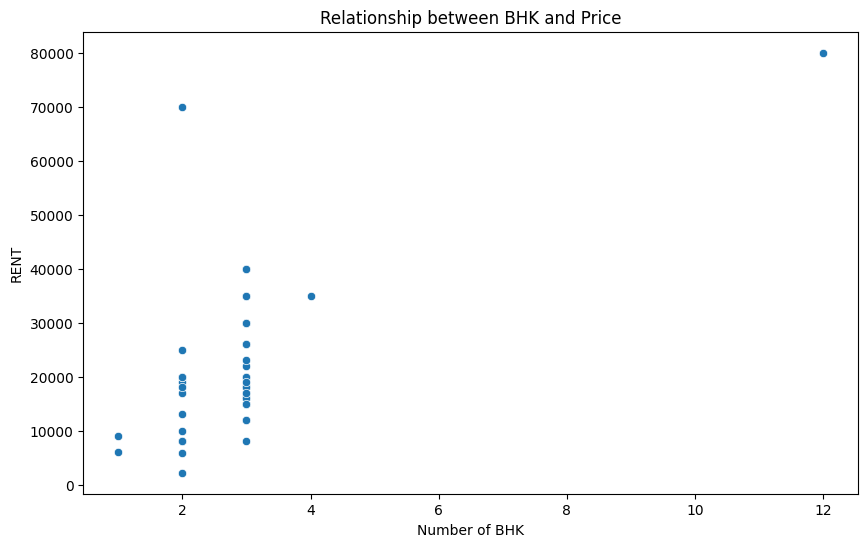

          PRICE       ADV      AREA       BHK
PRICE  1.000000  0.168056  0.221816  0.641997
ADV    0.168056  1.000000  0.139153  0.060080
AREA   0.221816  0.139153  1.000000  0.214614
BHK    0.641997  0.060080  0.214614  1.000000


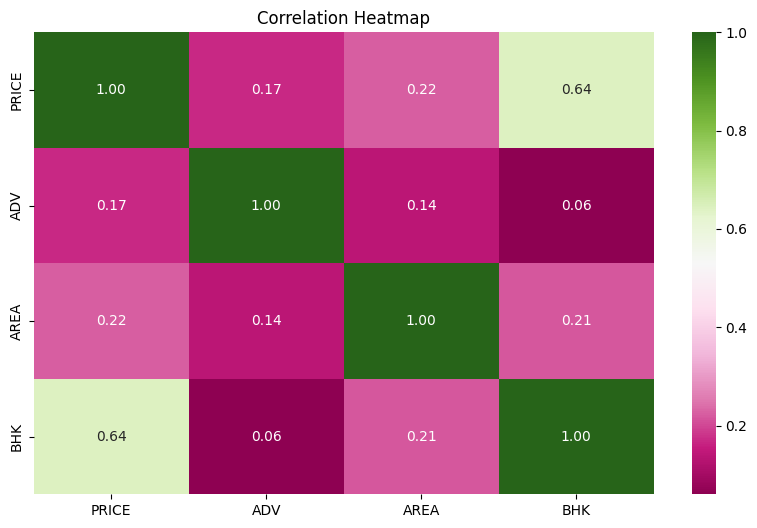

In [ ]:
##########################################################
####################### RANCHI  #############################


# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='PRICE', data=ranchi)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('RENT')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = ranchi[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['PRICE', 'ADV', 'AREA', 'BHK']
subset_df = ranchi[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#######################  RANCHI  #############################

# **JAMSHEDPUR**

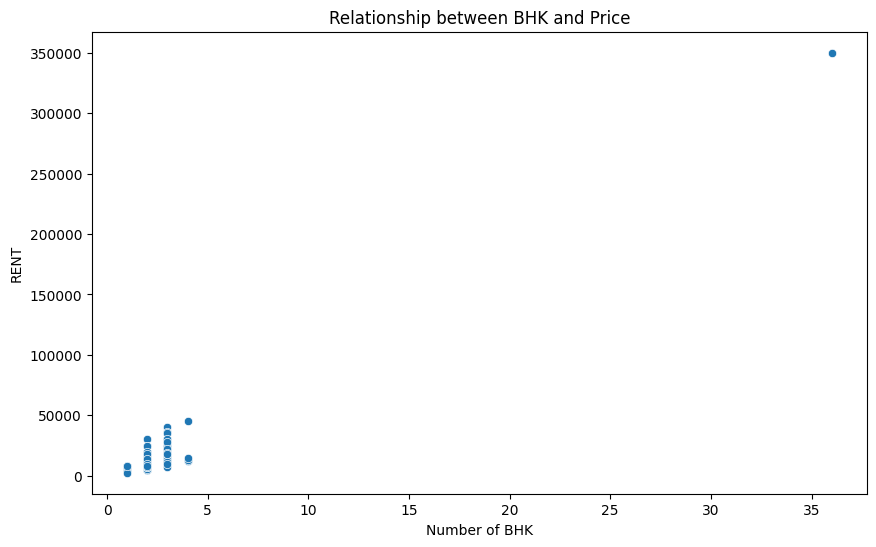

          PRICE      AREA       BHK
PRICE  1.000000  0.972513  0.971727
AREA   0.972513  1.000000  0.975860
BHK    0.971727  0.975860  1.000000


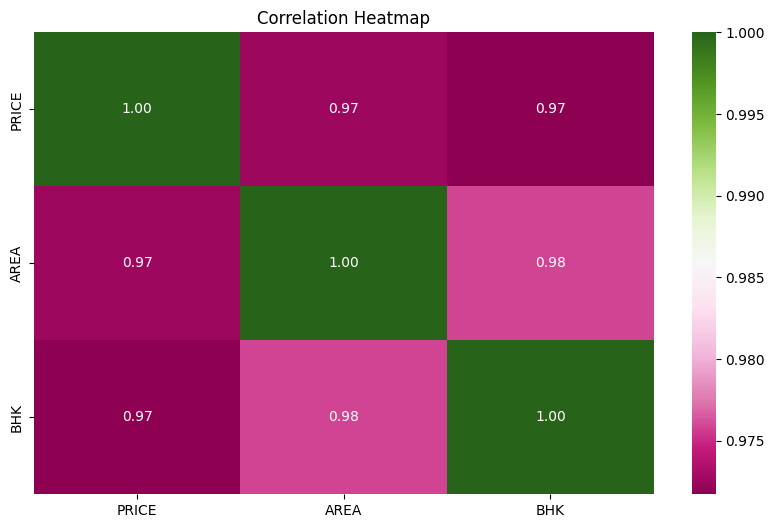

In [ ]:
##########################################################
####################### JAM #############################


# Create the scatter plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.scatterplot(x='BHK', y='PRICE', data=jam)
plt.title('Relationship between BHK and Price')
plt.xlabel('Number of BHK')
plt.ylabel('RENT')
plt.show()





# Assuming your dataframe is named 'df' and has columns 'T_PRICE', 'BHK', 'PER SQFT PRICE', and 'AMENITIES'
# Replace 'df' with the actual name of your dataframe if it's different

# Select the relevant columns
selected_columns = ['PRICE', 'AREA', 'BHK']
subset_df = jam[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Display the correlation matrix
print(correlation_matrix)





# Select the relevant columns
selected_columns = ['PRICE', 'AREA', 'BHK']
subset_df = jam[selected_columns]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#######################  JAMSHEDPUR   #############################